# Part A — Dataset Exploration

## 1. Understanding the Dataset

The Shopee Product Matching dataset contains product listings that may
represent the same underlying product.

Each training listing contains:
- `posting_id`: unique identifier for the listing.
- `image`: filename of the product image.
- `image_phash`: perceptual hash representing visual image characteristics.
- `title`: product title provided by the seller.
- `label_group`: identifier representing the underlying product group.

The `label_group` provides the ground-truth matching relationship in the
training data: listings with the same `label_group` belong to the same
product group.

In [21]:
# Configure the local Shopee dataset paths
from pathlib import Path

DATASET_DIR = Path(r"C:\Users\mahan\Downloads\shopee-product-matching")

TRAIN_PATH = DATASET_DIR / "train.csv"
TEST_PATH = DATASET_DIR / "test.csv"

TRAIN_IMAGES = DATASET_DIR / "train_images"
TEST_IMAGES = DATASET_DIR / "test_images"

In [22]:
# Load the Shopee training and test datasets
import pandas as pd

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nTraining data:")
display(train.head())

Train shape: (34250, 5)
Test shape: (3, 4)

Train columns:
['posting_id', 'image', 'image_phash', 'title', 'label_group']

Test columns:
['posting_id', 'image', 'image_phash', 'title']

Training data:


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


### Product Groups and Matching Relationship

The `label_group` column defines the matching relationship in the training
data.

Listings that share the same `label_group` are considered to represent the
same underlying product.

For example, if three listings have:

| Listing | `label_group` |
|---|---:|
| Listing A | 12345 |
| Listing B | 12345 |
| Listing C | 12345 |

then these three listings belong to the same product group.

A product group can contain multiple listings, and the listings within a
group may differ in their titles, images, or presentation.

Therefore, the matching task is not simply to find identical listings.
It is to determine which listings correspond to the same underlying
product.

## 2. Analyze the Dataset

We now examine the size and structure of the training dataset, followed by
product-group, image, and title characteristics.

# 2.1 :- Dataset Size

In [23]:
# Calculate the basic dataset counts
num_listings = len(train)
num_product_groups = train["label_group"].nunique()

print("Number of product listings:", num_listings)
print("Number of unique product groups:", num_product_groups)

Number of product listings: 34250
Number of unique product groups: 11014


### 2.1 Observation

The training dataset contains **34,250 product listings** belonging to
**11,014 unique product groups**.

Since there are substantially more listings than product groups, multiple
listings can represent the same underlying product. This makes the dataset
suitable for studying the product-matching problem.

# 2.2 No Of listings in a group vs No of group

In [24]:
# Calculate the number of listings in each product group
group_sizes = train["label_group"].value_counts()

print("Smallest group size:", group_sizes.min())
print("Largest group size:", group_sizes.max())
print("Average group size:", group_sizes.mean())
print("Median group size:", group_sizes.median())

print("\nNumber of groups by group size:")
print(group_sizes.value_counts().sort_index().head(20))

Smallest group size: 2
Largest group size: 51
Average group size: 3.109678590884329
Median group size: 2.0

Number of groups by group size:
count
2     6979
3     1779
4      862
5      468
6      282
7      154
8      118
9       91
10      48
11      38
12      39
13      28
14      19
15      19
16      13
17       9
18       5
19       5
20       6
21       6
Name: count, dtype: int64


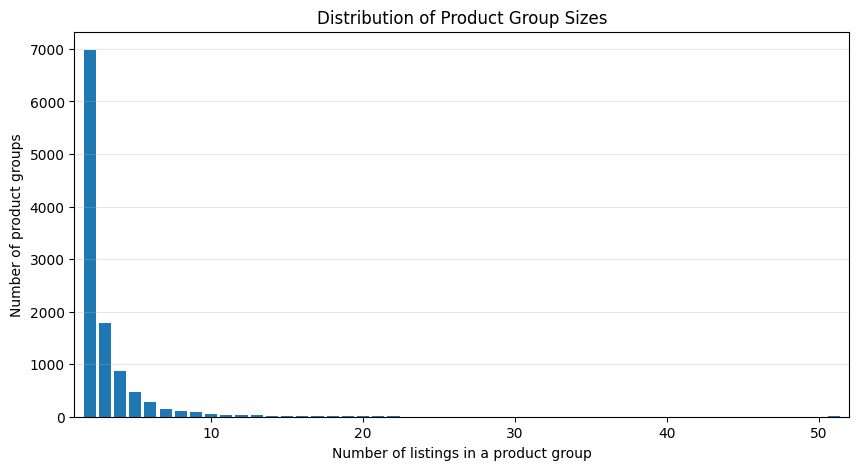

In [25]:
# Visualize the product-group size distribution
import matplotlib.pyplot as plt

group_size_counts = group_sizes.value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(group_size_counts.index, group_size_counts.values)

plt.xlabel("Number of listings in a product group")
plt.ylabel("Number of product groups")
plt.title("Distribution of Product Group Sizes")
plt.xlim(1, 52)
plt.grid(axis="y", alpha=0.3)

plt.show()

### 2.2 Observations

The product-group size distribution is strongly right-skewed.

- The smallest product groups contain **2 listings**.
- The largest product group contains **51 listings**.
- The mean group size is approximately **3.11 listings**.
- The median group size is **2 listings**.
- **6,979 product groups** contain exactly 2 listings.

Most product groups therefore contain only a small number of listings,
while a smaller number of groups contain many listings. This creates a
long-tailed distribution of product-group sizes.

# 2.3:- Analyze unique and repeated image files

In [26]:
# Analyze unique and repeated image files
image_counts = train["image"].value_counts()

num_unique_images = train["image"].nunique()
repeated_images = image_counts[image_counts > 1]

print("Number of unique images:", num_unique_images)
print("Number of repeated image files:", len(repeated_images))
print("Listings using repeated image files:", repeated_images.sum())

print("\nMost frequently reused images:")
print(repeated_images.head(10))

Number of unique images: 32412
Number of repeated image files: 1246
Listings using repeated image files: 3084

Most frequently reused images:
image
0cca4afba97e106abd0843ce72881ca4.jpg    15
c739a327dbeca472089a5195e898cce4.jpg    13
37c48fec3515e5245dff3dfe268b677b.jpg     9
9320d7a2181b28e6a61317e8ca06ffea.jpg     9
92394414388e82ccc782fae516933cb3.jpg     9
5ee62d13d49ea74cc3553f8ba5f6220d.jpg     9
27a805a3f09f52abdc06c063a08e2803.jpg     9
8c01557054b602566075868f3078e3b2.jpg     8
2247ba11aff46051df02ec5d386da107.jpg     8
9a061947211680e6475d3b98b477697d.jpg     8
Name: count, dtype: int64


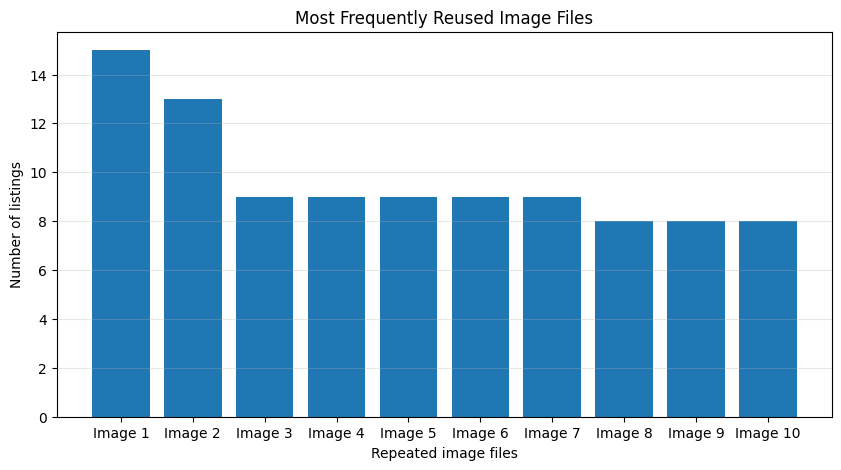

In [27]:
# Visualize the most frequently reused image files
top_repeated_images = repeated_images.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    range(len(top_repeated_images)),
    top_repeated_images.values
)

plt.xticks(
    range(len(top_repeated_images)),
    [f"Image {i+1}" for i in range(len(top_repeated_images))]
)
plt.xlabel("Repeated image files")
plt.ylabel("Number of listings")
plt.title("Most Frequently Reused Image Files")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 2.3 Observations

The dataset contains **32,412 unique image files** across **34,250
listings**.

A total of **1,246 image files** are reused across multiple listings,
accounting for **3,084 listing occurrences**.

The most frequently reused image appears in **15 different listings**.

This shows that exact image reuse is present in the dataset. However, image
reuse should not automatically be treated as proof that two listings belong
to the same product group, since an image may potentially be used across
different listings.

# 2.4 :- Analyze repeated perceptual image hashes

In [28]:
# Analyze repeated perceptual image hashes
phash_counts = train["image_phash"].value_counts()
repeated_phash = phash_counts[phash_counts > 1]

print("Number of unique image hashes:", train["image_phash"].nunique())
print("Number of repeated image hashes:", len(repeated_phash))
print("Listings with repeated image hashes:", repeated_phash.sum())

print("\nMost frequent repeated hashes:")
print(repeated_phash.head(10))

Number of unique image hashes: 28735
Number of repeated image hashes: 3229
Listings with repeated image hashes: 8744

Most frequent repeated hashes:
image_phash
fad28daa2ad05595    26
d0c0ea37bd9acce0    20
be12e12f9ec1e198    17
e992966d4ba49761    16
f6d98134b904b56b    16
ba96cc48cc63c56b    14
def6e14b4a398885    13
84563f696135c79a    13
ad29e81e92b295b5    12
ce2fa4d3959a51b0    12
Name: count, dtype: int64


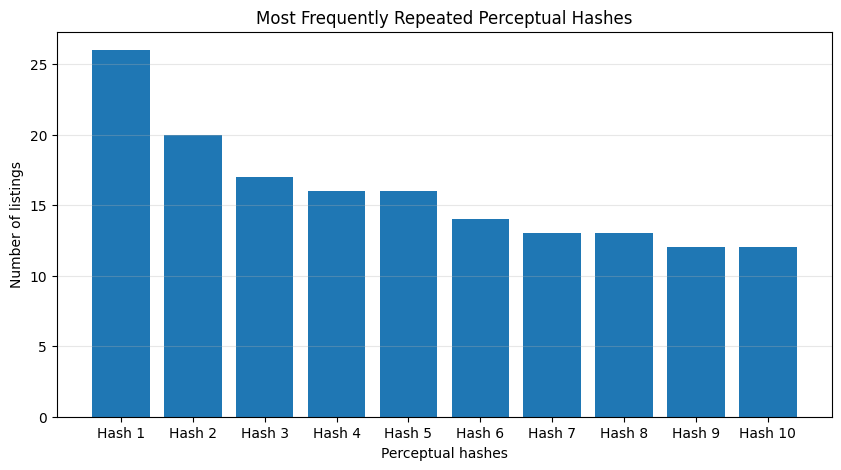

In [29]:
# Visualize the most frequently repeated perceptual hashes
top_repeated_phash = repeated_phash.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    range(len(top_repeated_phash)),
    top_repeated_phash.values
)

plt.xticks(
    range(len(top_repeated_phash)),
    [f"Hash {i+1}" for i in range(len(top_repeated_phash))]
)
plt.xlabel("Perceptual hashes")
plt.ylabel("Number of listings")
plt.title("Most Frequently Repeated Perceptual Hashes")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 2.4 Observations

The dataset contains **28,735 unique perceptual image hashes**.

There are **3,229 perceptual hashes** that occur in multiple listings,
covering **8,744 listing occurrences**.

The most frequently repeated perceptual hash appears in **26 listings**.

Unlike exact image filenames, perceptual hashes can capture visually similar
images even when the underlying image files are different. Therefore,
`image_phash` provides another potentially useful signal for product
matching.

However, repeated perceptual hashes do not necessarily imply identical
product identity, so their relationship with `label_group` needs to be
examined separately.

# 2.5:- duplicate-title analysis

In [30]:
# Normalize product titles for duplicate-title analysis
import re

def normalize_title(title):
    title = title.lower()
    title = re.sub(r"[^a-z0-9\s]", " ", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title

train["title_normalized"] = train["title"].apply(normalize_title)

title_counts = train["title_normalized"].value_counts()
repeated_titles = title_counts[title_counts > 1]

print("Unique normalized titles:", train["title_normalized"].nunique())
print("Repeated normalized titles:", len(repeated_titles))

print("\nMost frequent normalized titles:")
print(repeated_titles.head(10))

Unique normalized titles: 32389
Repeated normalized titles: 1481

Most frequent normalized titles:
title_normalized
viva air mawar                                                                                          14
koko syubbanul muslimin koko azzahir koko baju                                                          12
viva air mawar 100ml                                                                                    12
fanbo all in one deep cleansing balm                                                                     9
somebymi yuja niacin 30 days brightening starter kit                                                     9
emina glossy stain                                                                                       8
baju koko pria gus azmi syubbanul muslimin kombinasi hadroh azzahir hilw ho187 kemeja koko pria baju     8
bubble wrap                                                                                              7
somethinc aha bha pha peelin

In [31]:
# Find repeated titles that occur across multiple product groups
title_group_counts = train.groupby("title_normalized")["label_group"].nunique()

ambiguous_titles = title_group_counts[title_group_counts > 1]

print("Repeated normalized titles:", len(repeated_titles))
print("Repeated titles across multiple product groups:", len(ambiguous_titles))

print("\nExamples:")
print(ambiguous_titles.head(10))

Repeated normalized titles: 1481
Repeated titles across multiple product groups: 119

Examples:
title_normalized
100pcs ikat karet rambut elastis warna polos gaya korea untuk wanita                                    2
2kg shenar rak buku 3d 1x5 susun zaman now                                                              2
alat cukur rambut kumis jenggot nova ns 216                                                             2
alat pemisah putih kuning telur egg separator                                                           2
artline stix brush marker etx f                                                                         2
asah asahan pisau surmene stainless serbaguna knife grinder sharpener                                   3
b ns fc najibah gamis syar i asdf putih benhur abu toska navy maroon hujan muslim modis modern white    2
baju handuk handuk baju wearable towel new                                                              2
baju koko pria gus azmi syubbanul musli

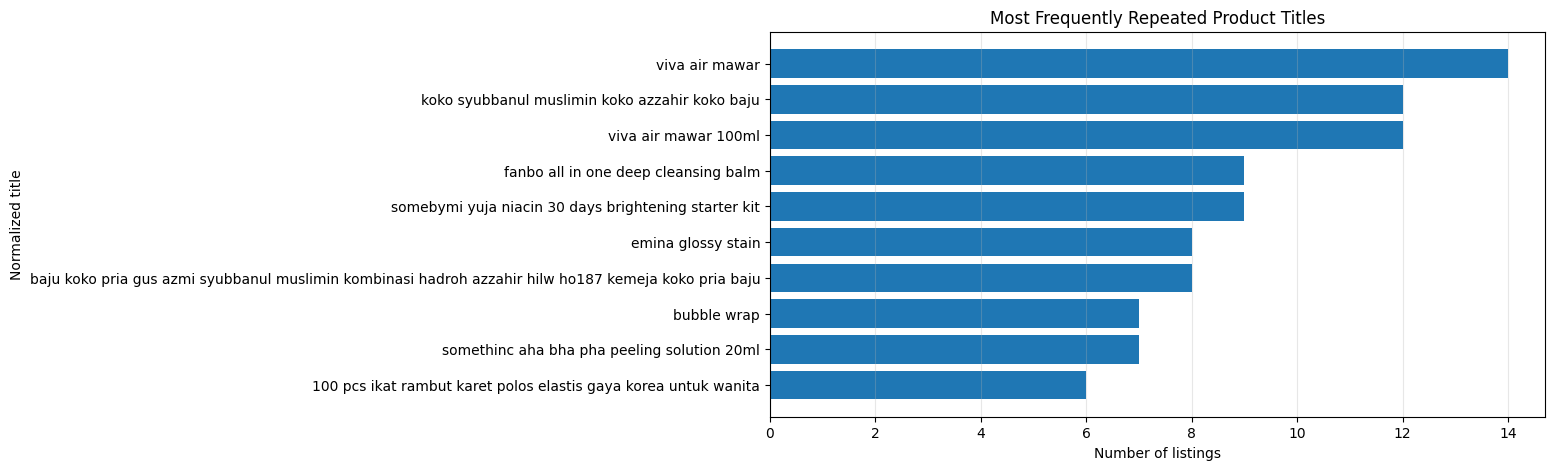

In [32]:
# Visualize the most frequently repeated normalized titles
top_repeated_titles = repeated_titles.head(10)

plt.figure(figsize=(10, 5))
plt.barh(
    top_repeated_titles.index[::-1],
    top_repeated_titles.values[::-1]
)

plt.xlabel("Number of listings")
plt.ylabel("Normalized title")
plt.title("Most Frequently Repeated Product Titles")
plt.grid(axis="x", alpha=0.3)

plt.show()

### 2.5 Observations

There are **32,389 unique normalized titles** among the 34,250 listings.

A total of **1,481 normalized titles** occur in more than one listing.
However, only **119 repeated titles** occur across multiple product groups.

This shows that repeated titles are common, but most repeated titles are
associated with the same product group.

At the same time, the 119 titles that occur across different product groups
demonstrate that identical or highly similar seller-written titles do not
always uniquely identify a product. This makes title matching alone
insufficient for reliable product matching.

# 2.6 :- word lengths of product titles

In [33]:
# Calculate character and word lengths of product titles
train["title_char_length"] = train["title"].str.len()
train["title_word_length"] = train["title"].str.split().str.len()

print("Character length:")
print("Minimum:", train["title_char_length"].min())
print("Maximum:", train["title_char_length"].max())
print("Mean:", train["title_char_length"].mean())
print("Median:", train["title_char_length"].median())

print("\nWord count:")
print("Minimum:", train["title_word_length"].min())
print("Maximum:", train["title_word_length"].max())
print("Mean:", train["title_word_length"].mean())
print("Median:", train["title_word_length"].median())

Character length:
Minimum: 5
Maximum: 357
Mean: 56.163474452554745
Median: 53.0

Word count:
Minimum: 1
Maximum: 61
Mean: 9.414861313868613
Median: 9.0


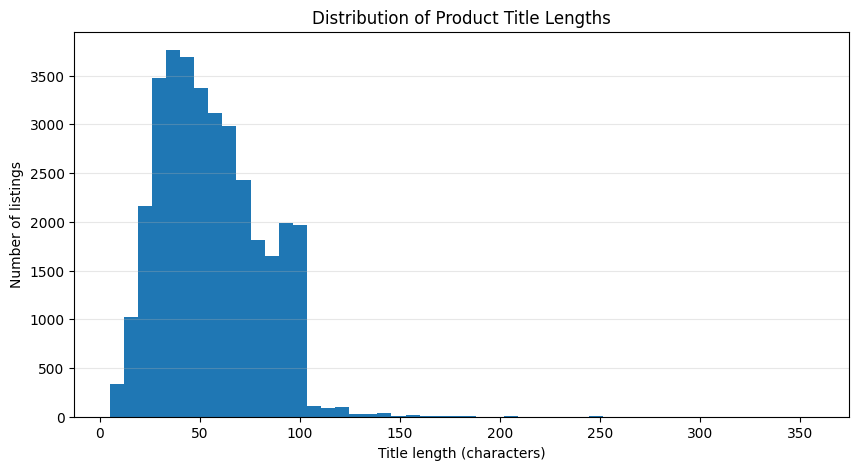

In [34]:
# Visualize the distribution of title character lengths
plt.figure(figsize=(10, 5))

plt.hist(train["title_char_length"], bins=50)

plt.xlabel("Title length (characters)")
plt.ylabel("Number of listings")
plt.title("Distribution of Product Title Lengths")
plt.grid(axis="y", alpha=0.3)

plt.show()

### 2.6 Observations

Product titles show substantial variation in length.

- Title length ranges from **5 to 357 characters**.
- The mean title length is approximately **56.16 characters**.
- The median title length is **53 characters**.
- Titles contain between **1 and 61 words**.
- The mean word count is approximately **9.41**, while the median is **9 words**.

The distribution is right-skewed, with most titles concentrated at shorter
lengths and a smaller number of very long titles.

This variation means that a text-based matching system must handle both short,
potentially incomplete titles and longer titles containing additional product
information.

# 2.7:- missing values and completely duplicated listings

In [35]:
# Check for missing values and completely duplicated listings
print("Missing values in each column:")
print(train[["posting_id", "image", "image_phash", "title", "label_group"]].isna().sum())

print("\nCompletely duplicated rows:", train.duplicated().sum())

Missing values in each column:
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

Completely duplicated rows: 0


### 2.7 Observations

All five original training columns contain **zero missing values**, and there
are **no completely duplicated rows**.

Therefore, missing values in the provided listing fields are not a major
characteristic of this training dataset. The main difficulty instead comes
from variation and ambiguity in the available information, such as different
titles, different images, repeated titles, and visually similar images.

# 3) Investigate Product Similarity

# 3.1 :- Multiple Listings Representing the Same Product

In [36]:
# Inspect all listings belonging to one product group
example_group = 258047

same_product = train[train["label_group"] == example_group]

print("Number of listings:", len(same_product))

display(
    same_product[
        ["posting_id", "image", "title", "label_group"]
    ]
)

Number of listings: 3


,posting_id,image,title,label_group
3874,train_1646767365,1d7aadc7503b2b4539cc9a5fe41979dd.jpg,Sarung celana wadimor original 100% dewasa dan...,258047
6738,train_398181303,3301b8aaccea93d1098995ffbc537335.jpg,SARUNG CELANA WADIMOR DEWASA HITAM POLOS SARCEL,258047
31859,train_1528423085,eec692257e74fcbc6cb63cb76d0f20e7.jpg,WARNA RANDOM ACAK Sarung Celana Wadimor MURAH ...,258047


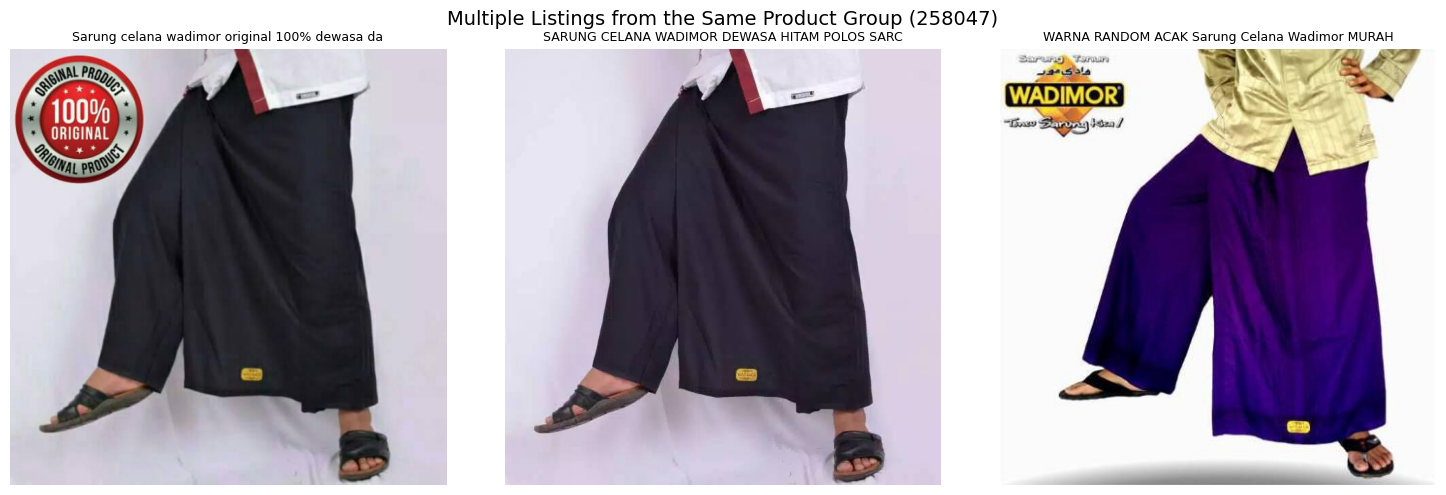

In [37]:
# Visualize all listings from the selected product group
from PIL import Image

fig, axes = plt.subplots(1, len(same_product), figsize=(15, 5))

for ax, (_, row) in zip(axes, same_product.iterrows()):
    image_path = TRAIN_IMAGES / row["image"]
    img = Image.open(image_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(row["title"][:45], fontsize=9)

plt.suptitle(
    f"Multiple Listings from the Same Product Group ({example_group})",
    fontsize=14
)
plt.tight_layout()
plt.show()

### 3.1 Example — Multiple Listings Representing the Same Product

The example product group `258047` contains three different listings.

Although the listings have different posting IDs, titles, and image files,
they all share the same `label_group` and therefore represent the same
underlying product.

This demonstrates that a product may have multiple seller listings with
different textual and visual representations. A product-matching system must
therefore identify the underlying product rather than simply detect identical
listings.

# 3.2 Same Product with Different Images

The Same analysis in 3.1 describes 3.2


### 3.2 Example — Same Product with Different Images

The example above also demonstrates that listings belonging to the same
product group can use different image files.

For `label_group = 258047`, all three listings use different image files
while still belonging to the same product group.

This means exact image matching cannot identify every instance of the same
product. A matching system must be able to recognize product identity across
different visual presentations.

# 3.3:- Similar Titles but Different Product Identities

In [38]:
# Inspect listings sharing a title across different product groups
example_title = ambiguous_titles.index[0]

similar_title_rows = train[
    train["title_normalized"] == example_title
]

print("Normalized title:")
print(example_title)

display(
    similar_title_rows[
        ["posting_id", "title", "image", "label_group"]
    ]
)

Normalized title:
100pcs ikat karet rambut elastis warna polos gaya korea untuk wanita


,posting_id,title,image,label_group
10412,train_880338666,100Pcs Ikat Karet Rambut Elastis Warna Polos G...,4e0bad1f97ab9bb4a196511d9c65629c.jpg,994676122
22505,train_2232408411,100Pcs Ikat Karet Rambut Elastis Warna Polos G...,a8f94251963c95d2b687fadf4ed9c99a.jpg,2045845868
32857,train_1157582002,100Pcs Ikat Karet Rambut Elastis Warna Polos G...,f6053a4f010a44f006e168a46e78332c.jpg,994676122


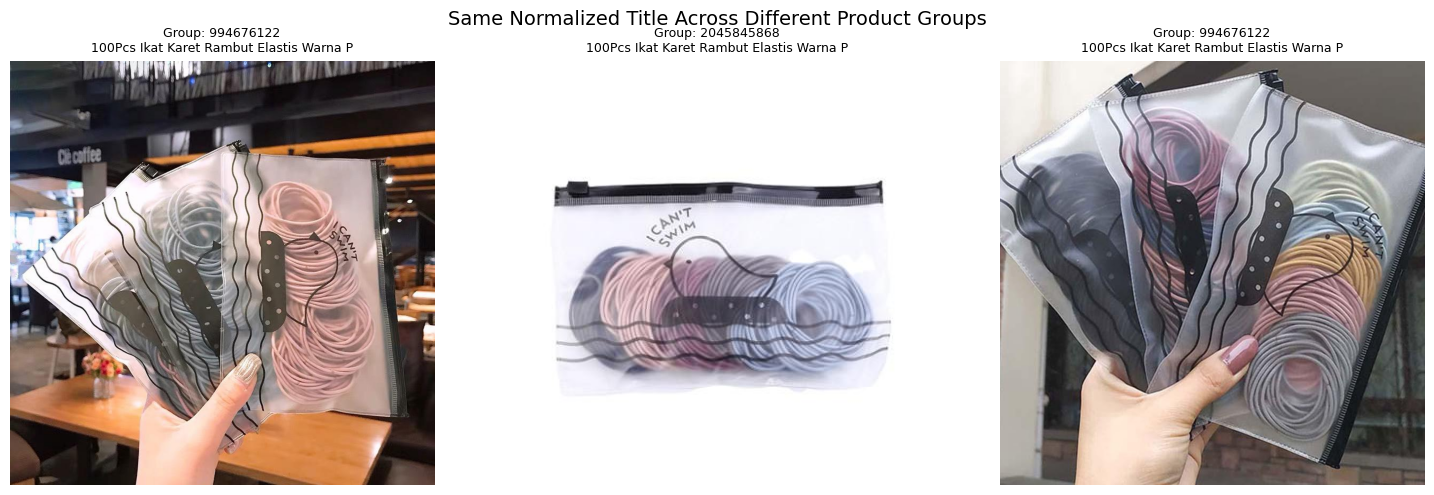

In [39]:
# Visualize listings with the same normalized title
fig, axes = plt.subplots(
    1, len(similar_title_rows),
    figsize=(15, 5)
)

for ax, (_, row) in zip(axes, similar_title_rows.iterrows()):
    image_path = TRAIN_IMAGES / row["image"]
    img = Image.open(image_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"Group: {row['label_group']}\n{row['title'][:40]}",
        fontsize=9
    )

plt.suptitle(
    "Same Normalized Title Across Different Product Groups",
    fontsize=14
)
plt.tight_layout()
plt.show()

### 3.3 Example — Similar Titles but Different Product Identities

The normalized title

`100pcs ikat karet rambut elastis warna polos gaya korea untuk wanita`

appears in listings belonging to two different product groups.

Two listings belong to `label_group = 994676122`, while another listing
belongs to `label_group = 2045845868`.

The listings therefore demonstrate that an identical normalized title does
not necessarily imply the same underlying product.

This can happen because seller titles may be generic and reused across
different listings. A text-based matching system that relies only on title
similarity could therefore produce false matches.

# 3.4 — visually similar images but different product identities

In [40]:
# Find a repeated perceptual hash shared by different product groups
ambiguous_phash = phash_group_counts[
    (phash_group_counts > 1) & (phash_counts > 1)
]

example_phash = ambiguous_phash.index[0]

phash_rows = train[
    train["image_phash"] == example_phash
]

print("Example perceptual hash:", example_phash)

display(
    phash_rows[
        ["posting_id", "image", "title", "label_group", "image_phash"]
    ]
)

Example perceptual hash: 84b67e8525cf3f02


,posting_id,image,title,label_group,image_phash
18519,train_2128191438,8ba1d4f291430f965878781c97ac25cc.jpg,JF -Kelambu Lipat / kelambu canopy / kelambu a...,1876943817,84b67e8525cf3f02
32157,train_1610221569,f1133d8acd4b9733e9ca661f9e39f863.jpg,KELAMBU LIPAT KELAMBU TIDUR KELAMBU TEMPAT TID...,2829310561,84b67e8525cf3f02


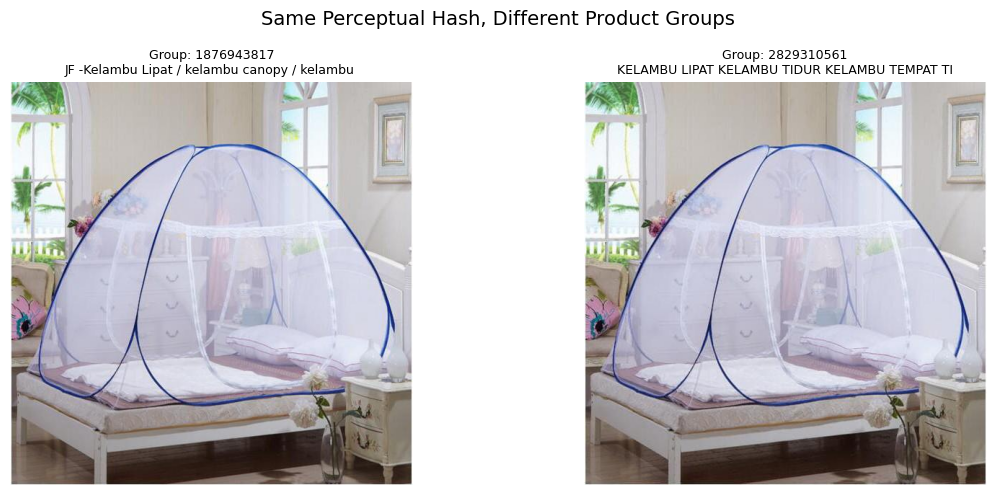

In [41]:
# Visualize listings sharing a perceptual hash but belonging to different groups
fig, axes = plt.subplots(1, len(phash_rows), figsize=(12, 5))

for ax, (_, row) in zip(axes, phash_rows.iterrows()):
    image_path = TRAIN_IMAGES / row["image"]
    img = Image.open(image_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"Group: {row['label_group']}\n{row['title'][:45]}",
        fontsize=9
    )

plt.suptitle(
    "Same Perceptual Hash, Different Product Groups",
    fontsize=14
)
plt.tight_layout()
plt.show()

### 3.4 Example — Visually Similar Images but Different Product Identities

The two listings above have the same perceptual hash
(`84b67e8525cf3f02`) and their images are visually almost identical.
However, they belong to different product groups:

- `label_group = 1876943817`
- `label_group = 2829310561`

The titles are also very similar, with both referring to a folding mosquito
net/canopy.

According to the dataset labels, these listings represent different product
identities despite their highly similar visual appearance.

This demonstrates that visual similarity alone is not sufficient for reliable
product matching. A model may need to combine visual information with textual
and other product-level signals.

# 3.5 Listings with noisy or incomplete information

In [42]:
# Find listings with the shortest product titles
shortest_titles = train.sort_values("title_word_length").head(10)

display(
    shortest_titles[
        ["posting_id", "title", "image", "label_group"]
    ]
)

,posting_id,title,image,label_group
25015,train_3551868579,Sendaljellybalance,bb0741f690b95f58d631f1959021b744.jpg,3302165411
4009,train_2307897736,fullo,1e74721f94e2ad18ea841ad9333d4fb3.jpg,1029271551
10594,train_19417841,Bendera,4f7a24de9f16e0a3cb5ae6f269b1120b.jpg,44523554
10925,train_1117202447,Eufloria,5209c7a540d58e58fd826b1a9ce86599.jpg,2945792466
10883,train_1612105644,Maskyourneeds,51bcee60d8f7cd5533759b28bfb843fe.jpg,656698835
10545,train_1926246953,STIMULANT,4f1eb3f5223d34bd64cb71c5d42eabd6.jpg,2542461348
11058,train_1580355342,Cansado,53209c4e95006d121ea118f2df435656.jpg,2734689090
1092,train_710383402,Caviplex,0894abd2767fcf962fe8959634cdb86f.jpg,4085784223
9510,train_779520769,tas/ransel/pria/cowok/anak/sekolah/sd/smp/sma/...,4773e4eb6e7f824689444fa9d045b63a.jpg,1012631413
6914,train_1514837750,Mayonnaise,3432f7578e361963b686d67106773991.jpg,2314234752


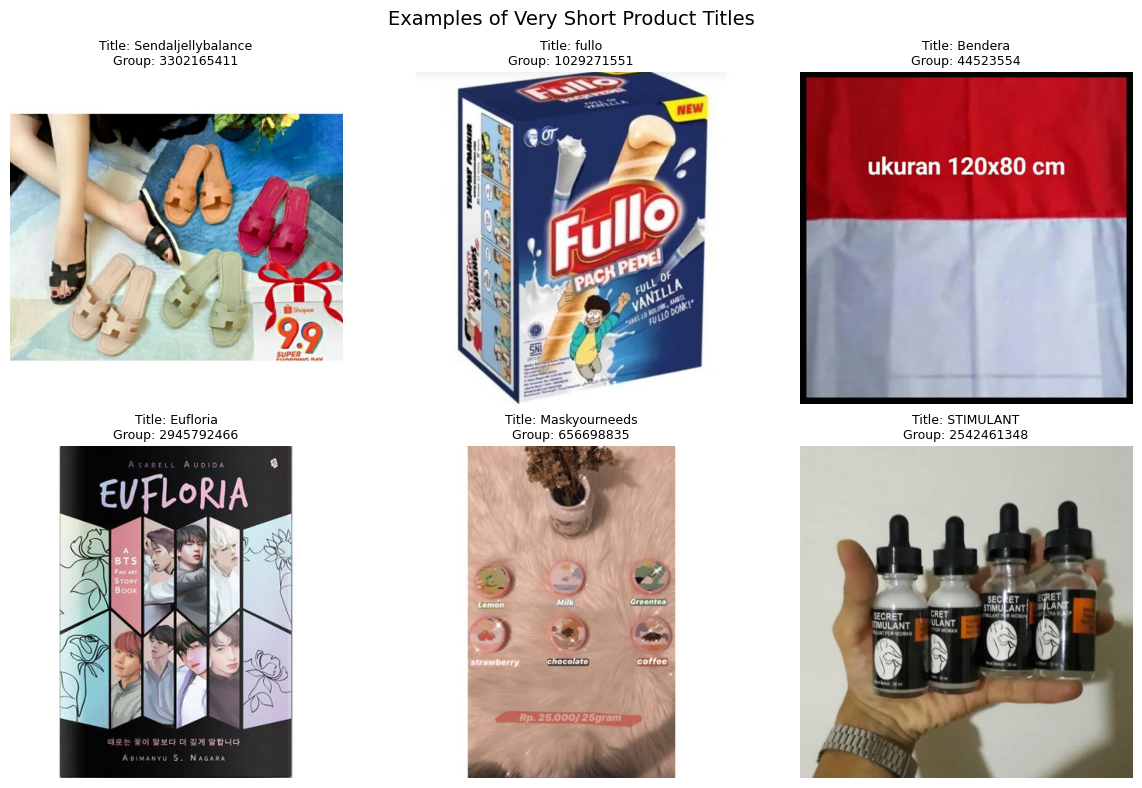

In [43]:
# Visualize listings with very short or uninformative titles
short_examples = shortest_titles.head(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, short_examples.iterrows()):
    image_path = TRAIN_IMAGES / row["image"]
    img = Image.open(image_path)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"Title: {row['title']}\nGroup: {row['label_group']}",
        fontsize=9
    )

plt.suptitle("Examples of Very Short Product Titles", fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Example — Noisy or Incomplete Listing Information

The examples above contain very short or weakly descriptive product titles.

For example, titles such as `Bendera`, `fullo`, `Eufloria`, and `Cansado`
provide little information about the specific product when considered
independently. In some cases, the title is primarily a brand or product name
rather than a detailed description.

The associated images provide substantially more information about the
products.

This demonstrates that product matching can be difficult when one modality
contains limited information. A robust matching system should therefore be
able to use complementary information from both text and images.

# 4. Identify Challenges

The analysis shows that product matching is difficult because neither text nor
images provide a completely reliable representation of product identity.

### 4.1 Noisy and Variable Product Titles

Seller-provided titles vary substantially in length, wording, and level of
detail. Titles range from **5 to 357 characters** and from **1 to 61 words**.

Some listings have very short or weakly descriptive titles, such as
`Bendera`, `fullo`, or `Eufloria`.

### 4.2 Reused or Generic Titles

We found **1,481 normalized titles** that occur in multiple listings, and
**119 of these occur across multiple product groups**.

Therefore, identical titles do not always indicate the same underlying
product. Generic or reused descriptions can create false matches.

### 4.3 Different Titles for the Same Product

We found **4,023 product groups** containing listings with both different
titles and different images.

This means the same product can be described differently by different
listings, making exact title matching insufficient.

### 4.4 Different Images for the Same Product

Listings belonging to the same product group can use different image files
and different visual presentations.

Consequently, exact image matching cannot identify all listings belonging to
the same product.

### 4.5 Visually Similar but Different Products

We found **147 repeated perceptual hashes** that occur across multiple
product groups.

This demonstrates that visually similar images can correspond to different
product identities. Image similarity alone can therefore produce false
matches.

### 4.6 Different Image Presentation

Images of the same product may differ in viewpoint, color, cropping,
background, or overall presentation.

A matching model must focus on product-relevant visual features rather than
relying only on pixel-level similarity.

### 4.7 Incomplete Information

Some listings provide very little useful information in their titles.
In such cases, the image may contain important information that is absent
from the text.

This makes it difficult to rely on a single modality.

### 4.8 Uneven Product-Group Sizes

Product groups are strongly right-skewed: the median group contains only
**2 listings**, while the largest group contains **51 listings**.

Therefore, some products have many examples while most groups have relatively
few listings. This creates unequal amounts of information available for
different product identities.

### 4.9 Multimodal Matching Requirement

Overall, the analysis suggests that reliable product matching requires
combining complementary signals.

Text can provide product names and descriptive attributes, while images can
capture visual characteristics that may be missing from titles. However,
both modalities can also be ambiguous.

A robust matching system should therefore consider **both textual and visual
similarity**, rather than depending on a single signal.

# 5. Questions to Consider

### What makes two listings belong to the same product?

Two listings belong to the same product when they represent the same underlying
product, even if their titles, images, or presentation differ.

The `label_group` provides the ground-truth product identity in the training
dataset. Our analysis showed that listings within the same group can have
different titles and different images.

Therefore, product identity is not determined by exact textual or visual
equality. Instead, relevant product characteristics may be expressed
differently across listings.

---

### Can product titles alone reliably determine whether two listings match?

No.

Title information is useful, but it is not sufficient by itself.

We found **4,023 product groups** containing listings with different titles
and different images, showing that the same product can be described using
different titles.

We also found **119 normalized titles** that occur across multiple product
groups. For example, the same normalized title can appear in listings that
belong to different product identities.

Therefore, title similarity can help identify potential matches, but relying
only on titles can both miss true matches and produce false matches.

---

### Can images alone reliably determine whether two listings match?

No.

Images provide an important signal, but they are also not sufficient by
themselves.

Listings belonging to the same product group can use different image files
and different visual presentations. At the same time, we found **147 repeated
perceptual hashes** that occur across multiple product groups.

One example showed two visually almost identical images with the same
perceptual hash but different `label_group` values.

Therefore, image similarity can help identify potential matches, but visually
similar products can still have different product identities.

---

### What types of examples are likely to be difficult for a machine learning model?

Based on the analysis, difficult cases include:

- The same product described using substantially different titles.
- The same product shown using different images or visual presentations.
- Generic or reused titles appearing across different products.
- Visually similar products belonging to different product groups.
- Very short or poorly descriptive titles.
- Listings where useful information is available mainly in one modality,
  such as the image but not the title.
- Product groups with very few listings, which provide fewer examples of
  how the same product can vary across listings.

These cases are difficult because the model must distinguish meaningful
product identity from superficial similarities and differences.

---

### What information in the dataset could potentially be useful for solving the problem?

Several fields provide potentially useful signals:

- **`title`** — provides textual information about the product, including
  names, brands, attributes, and descriptions.
- **`image`** — provides visual information about the product's appearance.
- **`image_phash`** — provides a compact representation that can help
  identify visually similar images.
- **`label_group`** — provides the ground-truth product identity during
  training and evaluation of matching approaches.
- **Multiple listings within the same `label_group`** — provide examples of
  how the same underlying product can vary in title and visual presentation.

The analysis suggests that combining textual and visual information could be
more useful than relying exclusively on either modality.

---

### Overall Conclusion

The exploratory analysis shows that Shopee product matching is fundamentally
a problem of identifying **underlying product identity despite variation in
how products are listed**.

Neither titles nor images are perfectly reliable on their own. The same
product may have different textual and visual representations, while
different products may have highly similar titles or images.

Therefore, the dataset motivates a **multimodal matching approach** that can
combine complementary information from product titles and images.